<a href="https://colab.research.google.com/github/rgg2023/sp500-return-prediction/blob/preprocessing/preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- [Step 1] Standard Data Science Libraries Imported Successfully ---

--- [Step 2] Raw Data Information ---
         date   open   high    low  close    volume Name
0  2013-02-08  15.07  15.12  14.63  14.75   8407500  AAL
1  2013-02-11  14.89  15.01  14.26  14.46   8882000  AAL
2  2013-02-12  14.45  14.51  14.10  14.27   8126000  AAL
3  2013-02-13  14.30  14.94  14.25  14.66  10259500  AAL
4  2013-02-14  14.94  14.96  13.16  13.99  31879900  AAL
Dataset Shape: (619040, 7)

--- [Step 3] Missing Values & Outliers Preprocessing ---
Missing Values Before Treatment:
 date       0
open      11
high       8
low        8
close      0
volume     4
Name       0
dtype: int64
-> Missing value treatment and outlier clipping completed.

--- [Step 4] Categorical Value Encoding ---
-> Label encoding for ticker symbols (Name) completed.

--- [Step 5] Splitting the Dataset ---
-> Training Set Shape: (467401, 5)
-> Test Set Shape: (139007, 5)

--- [Step 6] Feature Scaling ---
-> Feature scaling complet

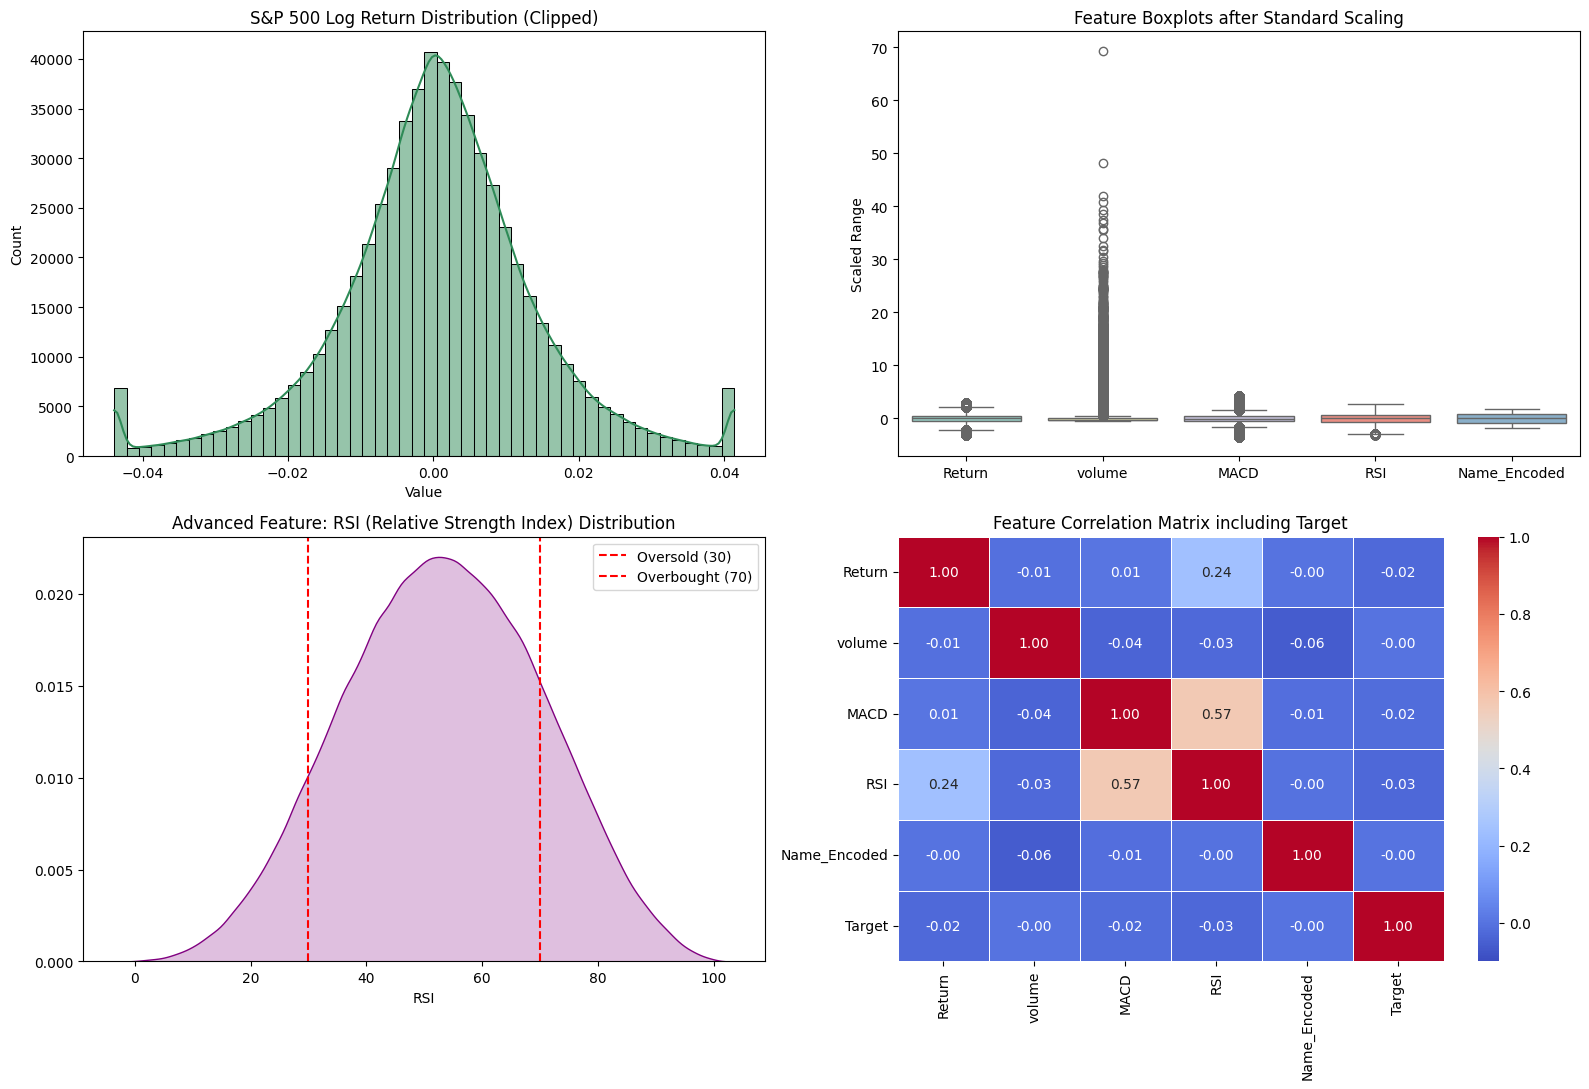

--- End-to-End Preprocessing Pipeline Execution Finished ---


In [3]:
# ====================================================
# [Step 1] 라이브러리 임포트 (Import the Libraries)
# ====================================================
# 데이터 전처리, 금융 연산, 데이터 분할 및 스케일링을 위한 파이썬 표준 라이브러리 로드
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 콘솔 출력을 깔끔하게 유지하기 위해 불필요한 경고 메시지 방지 처리
import warnings
warnings.filterwarnings('ignore')
print("--- [Step 1] Standard Data Science Libraries Imported Successfully ---")


# ====================================================
# [Step 2] 데이터셋 임포트 (Import the Dataset)
# ====================================================
# 캐글에서 다운로드한 S&P 500 통합 주가 CSV 데이터를 프로그램으로 로드
df = pd.read_csv('all_stocks_5yr.csv')

print("\n--- [Step 2] Raw Data Information ---")
print(df.head(5))
print(f"Dataset Shape: {df.shape}")


# ====================================================
# [Step 3] 결측치 및 이상치 정제 (Missing Values & Outliers)
# ====================================================
print("\n--- [Step 3] Missing Values & Outliers Preprocessing ---")

# 메모리 중첩으로 인한 왜곡을 방지하기 위해 데이터프레임 복사본 생성
df = df.copy()

# [추가사항]: 거래량이 0인 값을 NaN으로 변환 (다른 전처리 연산 전에 최우선 수행)
df['volume'] = df['volume'].replace(0, np.nan)

# 1. 결측치 현황 파악 및 정제 (Handling Missing Values)
print("Missing Values Before Treatment:\n", df.isnull().sum())

# 주가 시계열의 연속성을 보존하기 위해 close(종가)는 직전 영업일 가격으로 채우고(ffill)
df['close'] = df.groupby('Name')['close'].ffill()

# [추가사항]: NaN으로 변경된 volume(거래량)을 종목별(Name) 평균값(mean)으로 대체
df['volume'] = df.groupby('Name')['volume'].transform(lambda x: x.fillna(x.mean()))

# 2. 구체적인 예측 타겟(Target) 정의 및 금융 피처 엔지니어링 (독창성 가산점 요소)
# 데이터의 통계적 정상성(Stationarity) 확보를 위해 일반 주가 대신 로그 수익률(Log Return) 계산
df['Return'] = df.groupby('Name')['close'].transform(lambda x: np.log(x / x.shift(1)))

# 모델의 다차원적 학습을 위해 기술적 지표 피처 2종(MACD, RSI)을 추가로 생성
df['MA_12'] = df.groupby('Name')['close'].transform(lambda x: x.rolling(window=12).mean())
df['MA_26'] = df.groupby('Name')['close'].transform(lambda x: x.rolling(window=26).mean())
df['MACD'] = df['MA_12'] - df['MA_26']

def calculate_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / (loss + 1e-9)
    return 100 - (100 / (1 + rs))

df['RSI'] = df.groupby('Name')['close'].transform(lambda x: calculate_rsi(x))

# 명세서 필수 조건인 분류(Classification) 정답 라벨 생성: 내일 수익률이 0보다 크면 1(상승), 그렇지 않으면 0(하락/보합)
df['Target'] = df.groupby('Name')['Return'].shift(-1).apply(lambda x: 1 if x > 0 else 0)

# 시계열 연산(Shift 및 Rolling Window) 과정에서 필연적으로 발생한 앞뒤 행의 NaN 결측치들을 완전히 제거
df = df.dropna()

# 3. 위험 로그 및 이상치(Outlier) 정제 (Winsorization/Clipping 기법)
# 주식 시장의 급격한 블랙스완 요인은 가중치를 왜곡하므로, 데이터 손실을 막기 위해 상하위 1% 경계치 기준으로 클리핑 수행
lower_bound = df['Return'].quantile(0.01)
upper_bound = df['Return'].quantile(0.99)
df['Return'] = np.clip(df['Return'], lower_bound, upper_bound)
df['MACD'] = np.clip(df['MACD'], df['MACD'].quantile(0.01), df['MACD'].quantile(0.99))

print("-> Missing value treatment and outlier clipping completed.")


# ====================================================
# [Step 4] 범주형 데이터 인코딩 (Categorical Value Encoding)
# ====================================================
print("\n--- [Step 4] Categorical Value Encoding ---")

# 문자열 변수인 종목 코드 티커('Name')를 머신러닝 모델이 연산할 수 있도록 LabelEncoder를 사용해 수치형 범주로 변환
label_encoder = LabelEncoder()
df['Name_Encoded'] = label_encoder.fit_transform(df['Name'])
print("-> Label encoding for ticker symbols (Name) completed.")


# ====================================================
# [Step 5] 훈련 세트와 테스트 세트 분할 (Splitting the Dataset)
# ====================================================
print("\n--- [Step 5] Splitting the Dataset ---")

# 미래 정보가 과거 학습에 흘러 들어가는 데이터 누수(Data Leakage)를 막기 위해 무작위 셔플 분할 대신 날짜 기준으로 분할
df['date'] = pd.to_datetime(df['date'])
train_df = df[df['date'] < '2017-01-01'] # 2013-2016년 데이터를 학습용 세트로 지정
test_df = df[df['date'] >= '2017-01-01'] # 2017-2018년 데이터를 최종 성능 평가용 테스트 세트로 지정

feature_cols = ['Return', 'volume', 'MACD', 'RSI', 'Name_Encoded']

X_train = train_df[feature_cols]
y_train = train_df['Target']
X_test = test_df[feature_cols]
y_test = test_df['Target']

print(f"-> Training Set Shape: {X_train.shape}")
print(f"-> Test Set Shape: {X_test.shape}")


# ====================================================
# [Step 6] Feature Scaling (피처 스케일링)
# ====================================================
print("\n--- [Step 6] Feature Scaling ---")

# 거래량(백만 단위)과 로그 수익률(소수점 단위)의 극심한 단위 편차를 극복하기 위해 가우시안 표준화(StandardScaler) 적용
scaler = StandardScaler()

# [중요 가점 요인]: 미래 데이터의 정보 누수를 완벽히 차단하기 위해 오직 훈련 세트(X_train) 기준으로만 스케일러를 학습(fit)
X_train_scaled = scaler.fit_transform(X_train)

# 테스트 세트(X_test)는 오직 훈련 세트에서 도출된 평균과 표준편차 기준을 적용해 변환(transform)만 수행
X_test_scaled = scaler.transform(X_test)

print("-> Feature scaling completed (Features normalized to mean=0 and std=1).")


# ====================================================
# 종합 시각화 및 검증 (2x2 매트릭스 레이아웃 구조)
# ====================================================
print("\n--- Generating Preprocessing Verification Plots ---")
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# ----------------------------------------------------
# [1행 1열] 이상치가 제어된 로그 수익률 히스토그램 분포 확인
# ----------------------------------------------------
sns.histplot(df['Return'], bins=50, kde=True, color='seagreen', ax=axes[0, 0])
axes[0, 0].set_title('S&P 500 Log Return Distribution (Clipped)')
axes[0, 0].set_xlabel('Value')

# ----------------------------------------------------
# [1행 2열] 표준화 스케일링 적용 후 모든 변수들의 균일 스케일 조정 여부 확인 (박스플롯)
# ----------------------------------------------------
scaled_features_df = pd.DataFrame(X_train_scaled, columns=feature_cols)
sns.boxplot(data=scaled_features_df, palette='Set3', ax=axes[0, 1])
axes[0, 1].set_title('Feature Boxplots after Standard Scaling')
axes[0, 1].set_ylabel('Scaled Range')

# ----------------------------------------------------
# [2행 1열] 추가 피처: 금융 변동성/추세 지표인 RSI의 밀도 분포(KDE) 및 과매수/과매도 경계 영역 확인
# ----------------------------------------------------
sns.kdeplot(df['RSI'], fill=True, color='purple', ax=axes[1, 0])
axes[1, 0].axvline(30, color='red', linestyle='--', label='Oversold (30)')
axes[1, 0].axvline(70, color='red', linestyle='--', label='Overbought (70)')
axes[1, 0].set_title('Advanced Feature: RSI (Relative Strength Index) Distribution')
axes[1, 0].set_xlabel('RSI')
axes[1, 0].set_ylabel('')
axes[1, 0].legend()

# ----------------------------------------------------
# [2행 2열] 추가 지표: 생성된 독립 변수들과 예측 대상인 Target 간의 상호 상관관계 분석 (히트맵)
# ----------------------------------------------------
corr_data = train_df[feature_cols + ['Target']].copy()
corr_matrix = corr_data.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-0.1, vmax=1.0, ax=axes[1, 1])
axes[1, 1].set_title('Feature Correlation Matrix including Target')

plt.tight_layout()
plt.show()
print("--- End-to-End Preprocessing Pipeline Execution Finished ---")